In [1]:
import warnings
warnings.filterwarnings(
    "ignore",
    message="Cannot parse header or footer so it will be ignored",
    category=UserWarning,
    module="openpyxl.worksheet.header_footer"
)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="Set2")

In [2]:
file_path = Path("data") / "Sample - Superstore dataset.xlsx"

df = pd.read_excel(file_path, sheet_name="Orders")

df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Year-Month"] = df["Order Date"].dt.to_period("M").astype(str)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year-Month
0,1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2018-11
1,2,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2018-11
2,3,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2018-06
3,4,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2017-10
4,5,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2017-10


In [3]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")

Total Sales: $2,297,200.86
Total Profit: $286,397.02
Total Orders: 5,009
Total Customers: 793


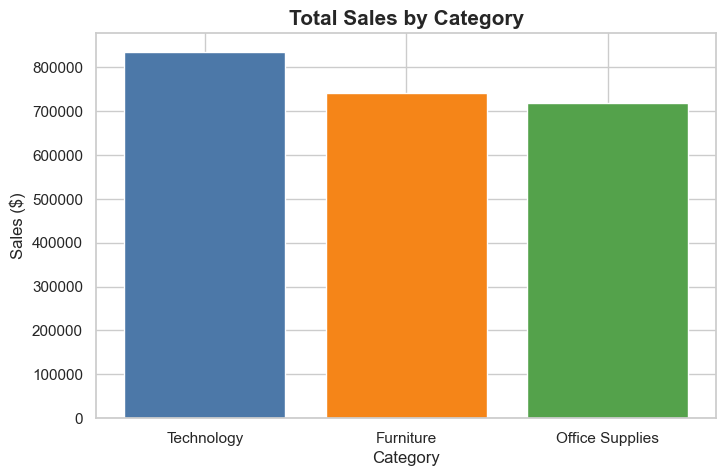

In [4]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(category_sales.index, category_sales.values,
        color=["#4C78A8", "#F58518", "#54A24B"])

plt.title("Total Sales by Category", fontsize=15, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Sales ($)")
plt.show()

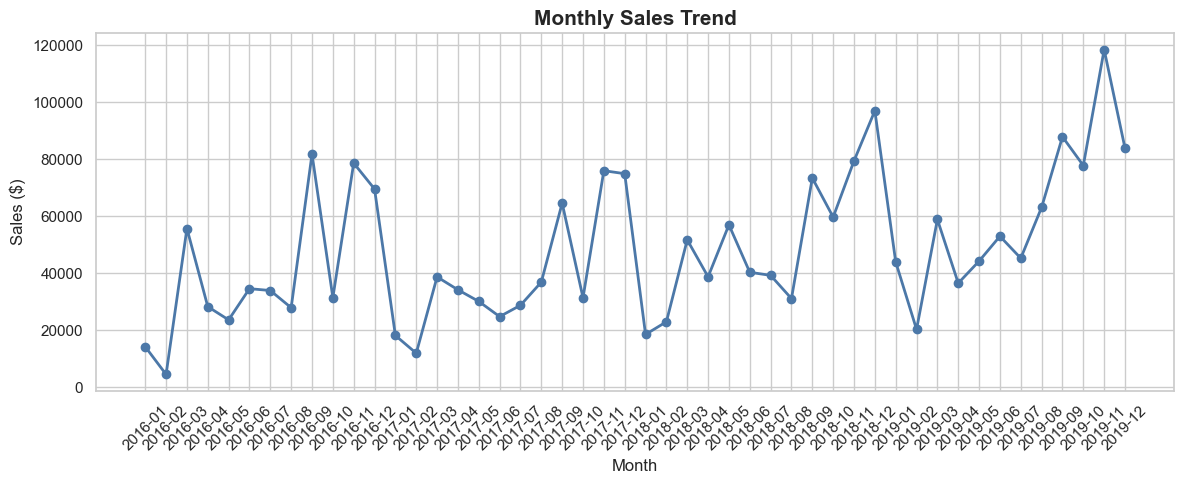

In [5]:
monthly_sales = df.groupby("Year-Month")["Sales"].sum()

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales.values,
         marker="o", color="#4C78A8", linewidth=2)

plt.title("Monthly Sales Trend", fontsize=15, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Sales ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

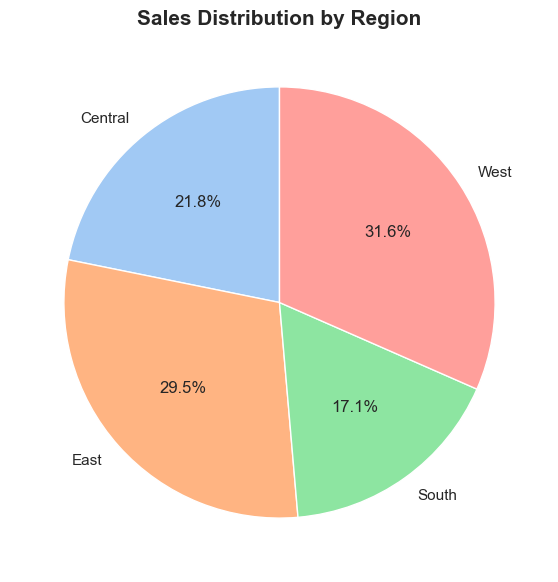

In [6]:
region_sales = df.groupby("Region")["Sales"].sum()

plt.figure(figsize=(7, 7))
plt.pie(
    region_sales.values,
    labels=region_sales.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("pastel")
)

plt.title("Sales Distribution by Region", fontsize=15, fontweight="bold")
plt.show()

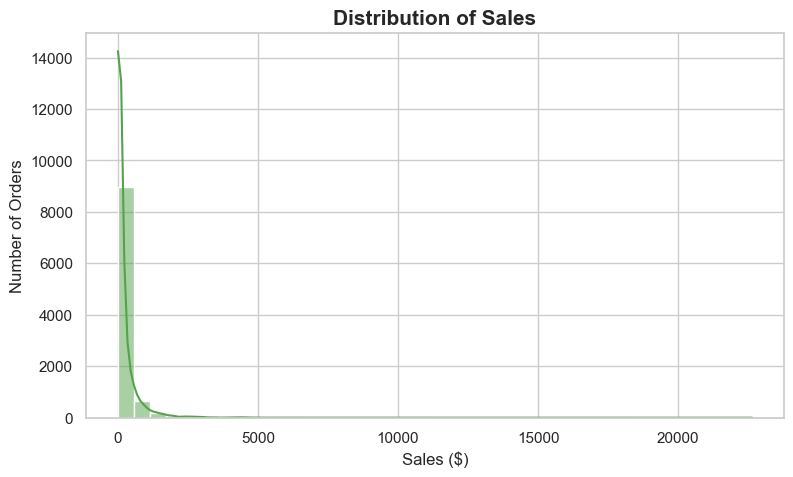

In [7]:
plt.figure(figsize=(9, 5))
sns.histplot(df["Sales"], bins=40, kde=True, color="#54A24B")

plt.title("Distribution of Sales", fontsize=15, fontweight="bold")
plt.xlabel("Sales ($)")
plt.ylabel("Number of Orders")
plt.show()

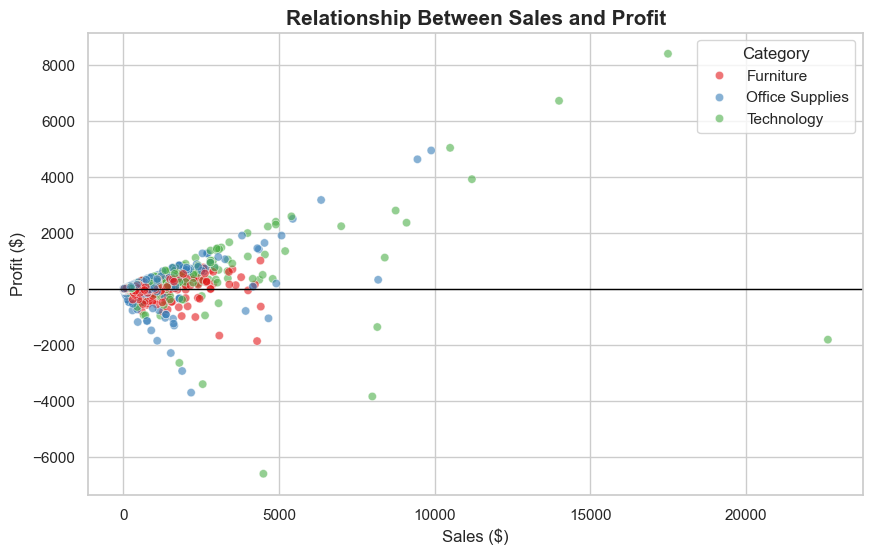

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Sales",
    y="Profit",
    hue="Category",
    palette="Set1",
    alpha=0.6
)

plt.axhline(0, color="black", linewidth=1)
plt.title("Relationship Between Sales and Profit", fontsize=15, fontweight="bold")
plt.xlabel("Sales ($)")
plt.ylabel("Profit ($)")
plt.legend(title="Category")
plt.show()

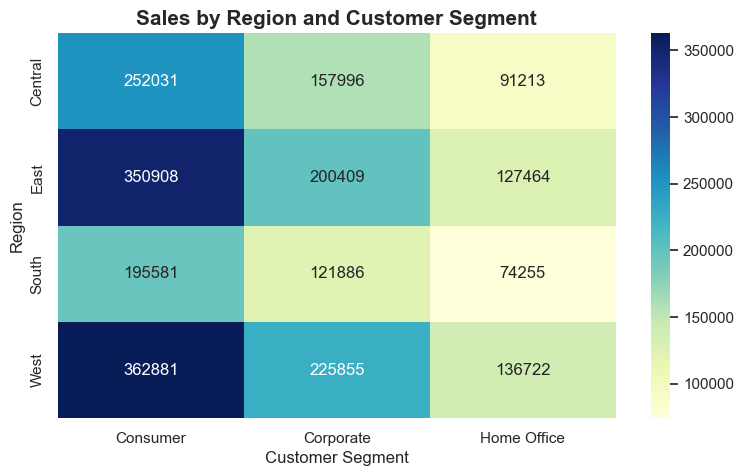

In [9]:
sales_heatmap = df.pivot_table(
    index="Region",
    columns="Segment",
    values="Sales",
    aggfunc="sum"
)

plt.figure(figsize=(9, 5))
sns.heatmap(sales_heatmap, annot=True, fmt=".0f", cmap="YlGnBu")

plt.title("Sales by Region and Customer Segment", fontsize=15, fontweight="bold")
plt.xlabel("Customer Segment")
plt.ylabel("Region")
plt.show()

# Dashboard Insights

- Technology and Furniture/Office Supplies can be compared to identify the highest-sales category.
- The monthly line chart shows sales growth and seasonal patterns.
- The regional pie chart shows each region’s contribution to total sales.
- The histogram shows that most orders have low-to-medium sales, while a few orders have very high sales.
- The scatter plot shows that high sales do not always guarantee high profit.
- The heatmap identifies high-performing region and customer-segment combinations.

## Conclusion

The dashboard makes Superstore business data easy to understand through multiple visualizations. It supports decisions related to product categories, customer segments, regional performance, and profitability.